# Data Wrangling with DataFrames Coding Quiz

Use this Jupyter notebook to find the answers to the quiz in the previous section. There is an answer key in the next part of the lesson.

In [1]:
# Import the necassary libraries
from pyspark.sql import SparkSession
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from pprint import pprint
from pyspark.sql import functions as F
from pyspark.sql import types as T

import datetime

In [2]:
# Instantiate a Spark session
spark = SparkSession \
    .builder \
    .appName("Udacity_DSND_P4") \
    .getOrCreate()

In [3]:
# Read in the dataset
path = "data/sparkify_log_small.json"              # Small dataset
path = "data/medium-sparkify-event-data.json"    # Medium dataset
df = spark.read.json(path)

print("The original dataset contains {} rows.".format(df.count()))
df.head()

The original dataset contains 543705 rows.


Row(artist='Martin Orford', auth='Logged In', firstName='Joseph', gender='M', itemInSession=20, lastName='Morales', length=597.55057, level='free', location='Corpus Christi, TX', method='PUT', page='NextSong', registration=1532063507000, sessionId=292, song='Grand Designs', status=200, ts=1538352011000, userAgent='"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/36.0.1985.125 Safari/537.36"', userId='293')

## 1. Data Exploration
First, we display the schema of the dataset and the number of rows.

In [4]:
print('\nThe schema:')
df.printSchema()


The schema:
root
 |-- artist: string (nullable = true)
 |-- auth: string (nullable = true)
 |-- firstName: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- itemInSession: long (nullable = true)
 |-- lastName: string (nullable = true)
 |-- length: double (nullable = true)
 |-- level: string (nullable = true)
 |-- location: string (nullable = true)
 |-- method: string (nullable = true)
 |-- page: string (nullable = true)
 |-- registration: long (nullable = true)
 |-- sessionId: long (nullable = true)
 |-- song: string (nullable = true)
 |-- status: long (nullable = true)
 |-- ts: long (nullable = true)
 |-- userAgent: string (nullable = true)
 |-- userId: string (nullable = true)



In [5]:
# Several rows contain information of events by non-logged in users. Drop them as non-informative
df.select('userID').groupby('userID').count().sort('count', ascending=False).show(3)
df = df.filter(df['userID'] != '')

print("The dataset contains {} rows.".format(df.count()))
print("The number of users is {}.".format(df.dropDuplicates(['userID']).count()))
print("The number of distinct sessions is {}".format(df.dropDuplicates(['sessionID']).count()))

+------+-----+
|userID|count|
+------+-----+
|      |15700|
|    92| 9767|
|   140| 7448|
+------+-----+
only showing top 3 rows

The dataset contains 528005 rows.
The number of users is 448.
The number of distinct sessions is 4470


In [6]:
# Find most popular artists and songs
df_artists = df.select('artist').dropna().groupby('artist').count().sort('count', ascending=False).toPandas()
df_songs = df.select('song').dropna().groupby('song').count().sort('count', ascending=False).toPandas()

print('The number of artists is {}'.format(len(df_artists)))
print('The number of songs is {}'.format(len(df_songs)))

The number of artists is 21247
The number of songs is 80292


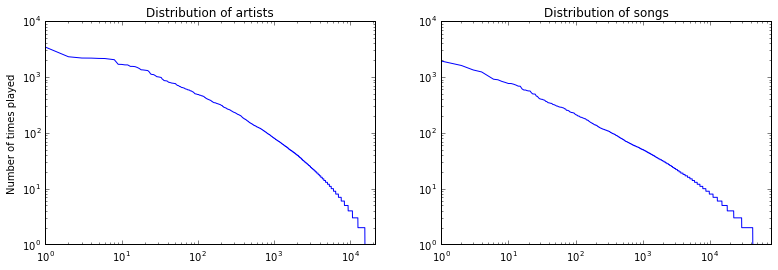

In [7]:
fig, ax = plt.subplots(1,2,figsize=(13,4))
df_artists['count'].plot(logx=True, logy=True, title='Distribution of artists', ax=ax[0])
df_songs['count'].plot(logy=True, logx=True, title='Distribution of songs', ax=ax[1])
ax[0].set_ylabel('Number of times played');

The main goal of this projust is to detect potential churn events (i.e. find users who are likely to cancel the service). We will also look at the possibility of users to downgrade and upgrade the service as alternative scenarios. In the (medium) datset, there are 99 instances of cancelling and almost 4000 instance of downgrading the service.

In [8]:
# Display different pages the users visited
df.select('page').groupby(['page']).count().sort('count', ascending=False).show()

+--------------------+------+
|                page| count|
+--------------------+------+
|            NextSong|432877|
|           Thumbs Up| 23826|
|                Home| 19089|
|     Add to Playlist| 12349|
|          Add Friend|  8087|
|         Roll Advert|  7773|
|              Logout|  5990|
|         Thumbs Down|  4911|
|           Downgrade|  3811|
|            Settings|  2964|
|                Help|  2644|
|               About|  1026|
|             Upgrade|   968|
|       Save Settings|   585|
|               Error|   503|
|      Submit Upgrade|   287|
|    Submit Downgrade|   117|
|              Cancel|    99|
|Cancellation Conf...|    99|
+--------------------+------+



Check the time period covered by the dataset to see how much data we have gathered. Also we display the distribution of events during the day. It looks uniform, which is a bit strange, since normally one would expect more usage during the day hours. A possible explanation for this might be that the dataset represents users located around the world, which smoothes the load on the servers (which doesn't seem to bethe case though).

The dataset covers the period of 61 days, 0:00:55:
from 2018-10-01 13:00:11
to 2018-12-01 13:01:06


(0, 25000)

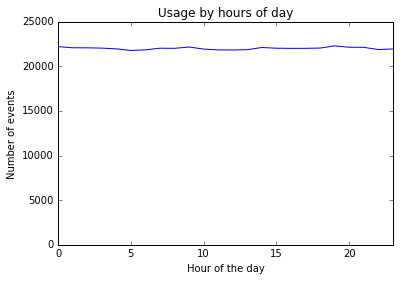

In [9]:
# Check the time period covered by the dataset
df = df.withColumn('date_hour', F.from_unixtime(df['ts']/1000, 'yyyy-MM-dd HH'))

firstObserved_datetime = datetime.datetime.fromtimestamp( df.agg({'ts':'min'}).collect()[0][0]/1000 )
lastObserved_datetime  = datetime.datetime.fromtimestamp( df.agg({'ts':'max'}).collect()[0][0]/1000 )
print("""The dataset covers the period of {}:\nfrom {}\nto {}""".format(lastObserved_datetime-firstObserved_datetime,\
                                                                        firstObserved_datetime, lastObserved_datetime))

# Plot the histogram of usage by hours
ax = df.select(F.from_unixtime(df['ts'], format='HH')\
          .cast('int').alias('hour')).groupby('hour')\
          .count().sort('hour').toPandas()['count'].plot(title='Usage by hours of day')
ax.set_xlabel('Hour of the day')
ax.set_ylabel('Number of events')
ax.set_ylim((0, 25000))

Mark each event in the dataset with the number of days since the user has been registered in the Service.

In [10]:
firstRegistered_datetime = datetime.datetime.fromtimestamp( df.agg({'registration':'min'}).collect()[0][0]/1000 )
lastRegistered_datetime  = datetime.datetime.fromtimestamp( df.agg({'registration':'max'}).collect()[0][0]/1000 )

print('First user registered on {}'.format(firstRegistered_datetime))
print('Last user registered on {}'.format(lastRegistered_datetime))

# df = df.withColumn('daysRegistered', \
#                    F.datediff(F.from_unixtime(df['ts']/1000),\
#                               F.from_unixtime(df['registration']/1000) )
#                   )

First user registered on 2017-11-05 16:56:33
Last user registered on 2018-11-25 04:37:54


In [11]:
df.filter(df['userID'] == 100051).withColumn('Registered', F.from_unixtime(df['registration']/1000, 'yyyy-MM-dd HH:mm:ss') ) \
              .withColumn('Observed', F.from_unixtime(df['ts']/1000, 'yyyy-MM-dd HH:mm:ss') )\
    .select(['Registered', 'Observed', 'page', 'sessionID']).show(100)

+-------------------+-------------------+--------------------+---------+
|         Registered|           Observed|                page|sessionID|
+-------------------+-------------------+--------------------+---------+
|2018-11-15 03:17:10|2018-11-14 10:10:16|                Home|       51|
|2018-11-15 03:17:10|2018-11-14 10:11:32|            NextSong|       51|
|2018-11-15 03:17:10|2018-11-14 10:11:55|         Roll Advert|       51|
|2018-11-15 03:17:10|2018-11-14 10:17:32|            NextSong|       51|
|2018-11-15 03:17:10|2018-11-14 10:17:33|          Add Friend|       51|
|2018-11-15 03:17:10|2018-11-14 10:19:09|                Home|       51|
|2018-11-15 03:17:10|2018-11-14 10:21:57|            NextSong|       51|
|2018-11-15 03:17:10|2018-11-14 10:27:04|            NextSong|       51|
|2018-11-15 03:17:10|2018-11-14 10:29:13|            NextSong|       51|
|2018-11-15 03:17:10|2018-11-14 10:32:48|            NextSong|       51|
|2018-11-15 03:17:10|2018-11-14 10:35:22|          

Next we find out how much data we have on those users who decided to cancel or downgrade.

In [12]:
# Find when the cancellations occured
F.to_date(F.lit(first))
df_cancel = df.filter(df['page']=='Cancel')\
              .withColumn('tsRegistered', F.from_unixtime(df['registration']/1000, 'yyyy-MM-dd HH:mm:ss') ) \
              .withColumn('tsObserved', F.from_unixtime(df['ts']/1000, 'yyyy-MM-dd HH:mm:ss') ) \
              .withColumn('daysObserved', \
                          F.datediff(F.from_unixtime(df['ts']/1000),\
                                     F.to_date(F.lit(first)) ) \
                         ) \
              .withColumn('daysRegistered', \
                          F.datediff(F.from_unixtime(df['ts']/1000),\
                                     F.from_unixtime(df['registration']/1000) )
                      )
              
        
df_cancel.select(['userID','daysObserved', 'daysRegistered', 'tsRegistered', 'tsObserved']).show(100)

NameError: name 'first' is not defined

In [8]:
There are 

964

# Question 1

Which page did user id "" (empty string) NOT visit?

In [26]:
# TODO: write your code to answer question 1
all_pages = user_log.select('page').dropDuplicates().sort('page')
this_user = user_log.filter("userId == ''").select('page').dropDuplicates().sort('page')

all_pages.show()
this_user.show()

# not_visited:
set(all_pages.toPandas().page).difference(this_user.toPandas().page)

+----------------+
|            page|
+----------------+
|           About|
|       Downgrade|
|           Error|
|            Help|
|            Home|
|           Login|
|          Logout|
|        NextSong|
|   Save Settings|
|        Settings|
|Submit Downgrade|
|  Submit Upgrade|
|         Upgrade|
+----------------+

+-----+
| page|
+-----+
|About|
| Help|
| Home|
|Login|
+-----+



{'Downgrade',
 'Error',
 'Logout',
 'NextSong',
 'Save Settings',
 'Settings',
 'Submit Downgrade',
 'Submit Upgrade',
 'Upgrade'}

# Question 2 - Reflect

What type of user does the empty string user id most likely refer to?


In [2]:
# TODO: use this space to explore the behavior of the user with an empty string


# Question 3

How many female users do we have in the data set?

In [27]:
# TODO: write your code to answer question 3
user_log.filter("gender == 'F'").select('userID').dropDuplicates().count()

462

# Question 4

How many songs were played from the most played artist?

In [56]:
# TODO: write your code to answer question 4
from pyspark.sql.functions import col

user_log.filter("page=='NextSong'").groupBy("artist").count().sort("count", ascending=False).show()
user_log.filter( col('artist')=='Coldplay' ).groupby('song').count().sort('count', ascending=False).show(53)

+--------------------+-----+
|              artist|count|
+--------------------+-----+
|            Coldplay|   83|
|       Kings Of Leon|   69|
|Florence + The Ma...|   52|
|            BjÃÂ¶rk|   46|
|       Dwight Yoakam|   45|
|       Justin Bieber|   43|
|      The Black Keys|   40|
|         OneRepublic|   37|
|                Muse|   36|
|        Jack Johnson|   36|
|           Radiohead|   31|
|        Taylor Swift|   29|
|               Train|   28|
|Barry Tuckwell/Ac...|   28|
|          Lily Allen|   28|
|          Nickelback|   27|
|           Daft Punk|   27|
|           Metallica|   27|
|          Kanye West|   26|
|Red Hot Chili Pep...|   24|
+--------------------+-----+
only showing top 20 rows

+--------------------+-----+
|                song|count|
+--------------------+-----+
|              Yellow|   21|
|              Clocks|   12|
|       The Scientist|   11|
|             Fix You|    8|
|              Shiver|    8|
|         In My Place|    4|
|             Tro

# Question 5 (challenge)

How many songs do users listen to on average between visiting our home page? Please round your answer to the closest integer.



In [77]:
# TODO: write your code to answer question 5
from pyspark.sql import Window
df = user_log.filter(col('page').isin(['Home','NextSong'])).select(['page','userID','ts', 'sessionID']).sort('ts')
df.groupby('sessionID').count().agg({"count":"avg"}).show()

+-----------------+
|       avg(count)|
+-----------------+
|6.422372881355932|
+-----------------+



In [83]:
# TODO: filter out 0 sum and max sum to get more exact answer
from pyspark.sql.functions import udf, desc
from pyspark.sql.types import IntegerType
from pyspark.sql.functions import sum as Fsum

function = udf(lambda ishome : int(ishome == 'Home'), IntegerType())

user_window = Window \
    .partitionBy('userID') \
    .orderBy(desc('ts')) \
    .rangeBetween(Window.unboundedPreceding, 0)

cusum = df.filter((df.page == 'NextSong') | (df.page == 'Home')) \
    .select('userID', 'page', 'ts') \
    .withColumn('homevisit', function(col('page'))) \
    .withColumn('period', Fsum('homevisit').over(user_window))

cusum.filter((cusum.page == 'NextSong')) \
    .groupBy('userID', 'period') \
    .agg({'period':'count'}) \
    .agg({'count(period)':'avg'}).show()

+------------------+
|avg(count(period))|
+------------------+
| 6.898347107438017|
+------------------+

